# Credit Card Spending Analysis

## Business Objective
The objective of this project is to analyze credit card spending patterns across cities, card types, expense categories, and gender to identify key spending behaviors and trends.

## Dataset Overview

The dataset contains credit card transaction records with the following fields:

- City
- Date
- Card Type
- Expense Type
- Gender
- Amount

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Data Understanding
data = pd.read_csv("Credit card transactions - India - Simple.csv")

rows, cols = data.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

print('\nColumns Name')
print(data.columns.tolist())

print('\nInfo about data')
data.info()

print('\nCount of Missing Values')
print(data.isnull().sum())

print('\nDuplicate Entries')
print(data.duplicated().sum())


Rows: 26052
Columns: 7

Columns Name
['index', 'City', 'Date', 'Card Type', 'Exp Type', 'Gender', 'Amount']

Info about data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26052 entries, 0 to 26051
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      26052 non-null  int64 
 1   City       26052 non-null  object
 2   Date       26052 non-null  object
 3   Card Type  26052 non-null  object
 4   Exp Type   26052 non-null  object
 5   Gender     26052 non-null  object
 6   Amount     26052 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.4+ MB

Count of Missing Values
index        0
City         0
Date         0
Card Type    0
Exp Type     0
Gender       0
Amount       0
dtype: int64

Duplicate Entries
0


In [66]:
#Which cities contribute the highest total spending?
city_spending = data.groupby('City')['Amount'].sum().sort_values(ascending=False)
print("City Spending")
print(city_spending.head(10))

#Which card type contribute the highest total spending?
card_spending = data.groupby('Card Type')['Amount'].sum().sort_values(ascending=False)
print("\nCard Type Spending")
print(card_spending)

#Which Expense type contribute the highest total spending?
exp_spending = data.groupby('Exp Type')['Amount'].sum().sort_values(ascending =False)
print("\nExpense Type Spending")
print(exp_spending)

#How gender is related to spending
gender_spending = data.groupby('Gender')['Amount'].sum().sort_values(ascending=False)
print("\nGender Type Spending")
print(gender_spending)

City Spending
City
Greater Mumbai, India    576751476
Bengaluru, India         572326739
Ahmedabad, India         567794310
Delhi, India             556929212
Kolkata, India           115466943
Lucknow, India           115334476
Chennai, India           114730600
Hyderabad, India         114493477
Surat, India             114486151
Kanpur, India            114370532
Name: Amount, dtype: int64

Card Type Spending
Card Type
Silver       1069613713
Signature    1013041105
Platinum     1007639019
Gold          984539536
Name: Amount, dtype: int64

Expense Type Spending
Exp Type
Bills            907072473
Food             824724009
Fuel             789135821
Entertainment    726437536
Grocery          718207923
Travel           109255611
Name: Amount, dtype: int64

Gender Type Spending
Gender
F    2205311030
M    1869522343
Name: Amount, dtype: int64


In [6]:
top_ten_cities = city_spending.head(10)

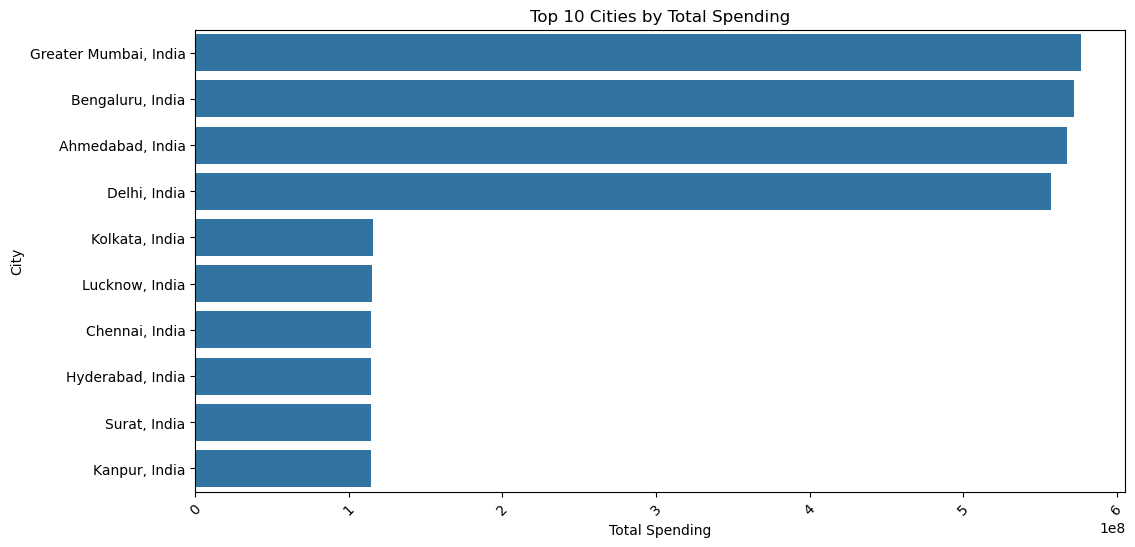

In [61]:
plt.figure(figsize=(12,6))
sns.barplot(x = top_ten_cities.values,y=top_ten_cities.index)
plt.title("Top 10 Cities by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("City")
plt.xticks(rotation=45)
plt.show()

## Observation:

1) Greater Mumbai has the highest total spending.
2) Bengaluru, Ahmedabad, and Delhi follow closely.
3) There is a significant drop in spending after the top four cities.

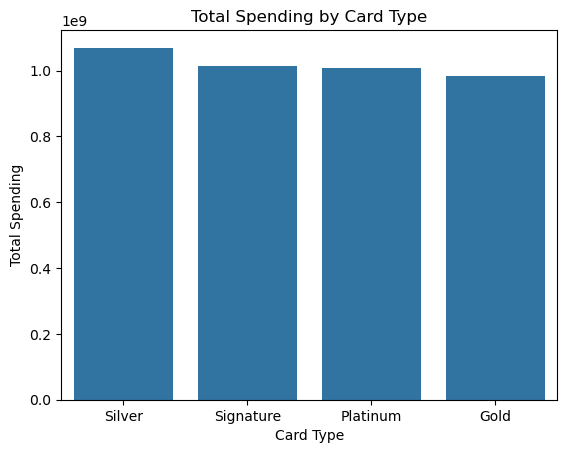

In [63]:
sns.barplot(x = card_spending.index,y=card_spending.values)
plt.title('Total Spending by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Total Spending')
plt.show()

## Observation:

1) Silver cards contribute the highest total spending.
2) Gold cards contribute the lowest total spending.
3) Spending is relatively balanced across all card types.

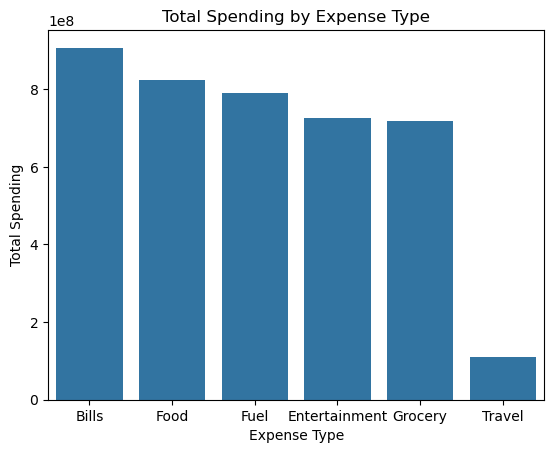

In [64]:
sns.barplot(x = exp_spending.index,y=exp_spending.values)
plt.title('Total Spending by Expense Type')
plt.xlabel('Expense Type')
plt.ylabel('Total Spending')
plt.show()

## Observation:

1) Bills account for the highest spending category.
2) Food and Fuel are also major spending categories.
3) Travel contributes the lowest total spending.

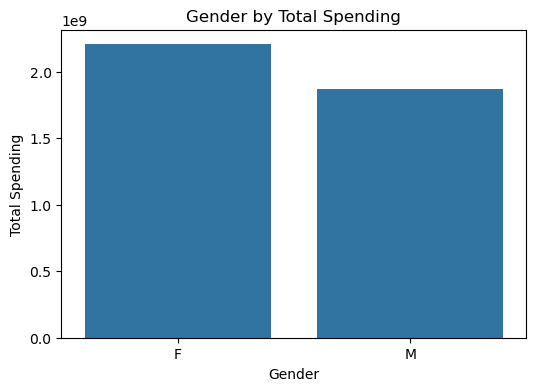

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=gender_spending.index,
    y=gender_spending.values
)

plt.title("Gender by Total Spending")
plt.xlabel("Gender")
plt.ylabel("Total Spending")

plt.show()

## Observations

1)Female customers contribute a higher total spending amount than male customers.

2)The gap between female and male spending is noticeable, indicating that female customers account for a larger share of overall credit card expenditure in the dataset.

In [11]:
gender_avg = data.groupby('Gender')['Amount'].mean()
print(gender_avg)

Gender
F    161206.946637
M    151109.145086
Name: Amount, dtype: float64


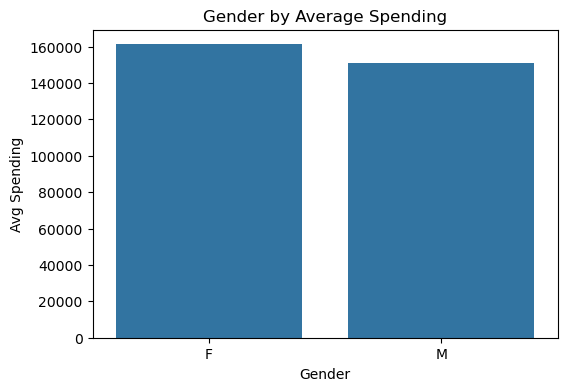

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=gender_avg.index,
    y=gender_avg.values
)

plt.title("Gender by Average Spending")
plt.xlabel("Gender")
plt.ylabel("Avg Spending")

plt.show()

## Observation

Female customers not only contribute higher total spending but also have a higher average transaction value.

In [51]:
gender_exp_spending = data.groupby(['Gender','Exp Type'])['Amount'].sum().reset_index()
print('Total Spending by Gender Type and Expense Type')
gender_exp_spending['Amount crore']=gender_exp_spending['Amount']/10000000
gender_exp_spending

Total Spending by Gender Type and Expense Type


,Gender,Exp Type,Amount,Amount crore
0,F,Bills,580035469,58.003547
1,F,Entertainment,358663333,35.866333
2,F,Food,452817279,45.281728
3,F,Fuel,392282421,39.228242
4,F,Grocery,365646998,36.564700
5,F,Travel,55865530,5.586553
6,M,Bills,327037004,32.703700
7,M,Entertainment,367774203,36.777420
8,M,Food,371906730,37.190673
9,M,Fuel,396853400,39.685340


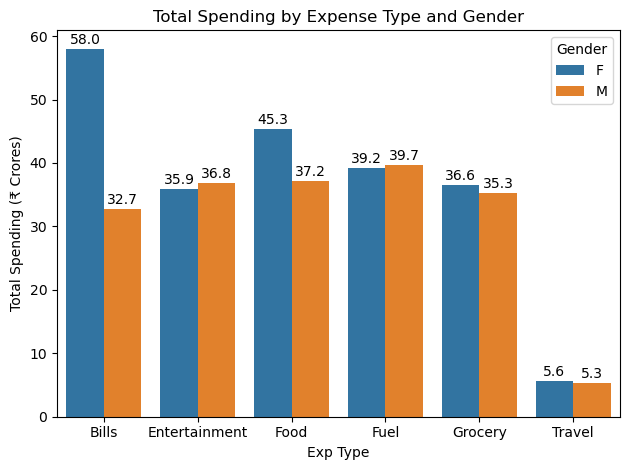

In [52]:
ax = sns.barplot(data=gender_exp_spending,x='Exp Type',y='Amount crore',hue='Gender')

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f',padding=1.5)

plt.title('Total Spending by Expense Type and Gender')
plt.ylabel('Total Spending (₹ Crores)')
plt.tight_layout()
plt.show()

## Observations:

1) Female customers spend significantly more on Bills than male customers.
2) Female customers also spend more on Food and Grocery categories.
3) Male customers spend slightly more on Entertainment and Fuel.
4) Travel spending is nearly equal across both genders.
5) Bills represent the highest spending category for females, while Fuel is the highest spending category for males.

In [68]:
card_exp_spending = data.groupby(['Card Type','Exp Type'])['Amount'].sum().reset_index() 
card_exp_spending['Amount Crore'] = card_exp_spending['Amount']/10000000
card_exp_spending

,Card Type,Exp Type,Amount,Amount Crore
0,Gold,Bills,225533948,22.553395
1,Gold,Entertainment,173468463,17.346846
2,Gold,Food,193756454,19.375645
3,Gold,Fuel,194343922,19.434392
4,Gold,Grocery,166246853,16.624685
5,Gold,Travel,31189896,3.118990
6,Platinum,Bills,222027597,22.202760
7,Platinum,Entertainment,185608738,18.560874
8,Platinum,Food,210318810,21.031881
9,Platinum,Fuel,194069361,19.406936


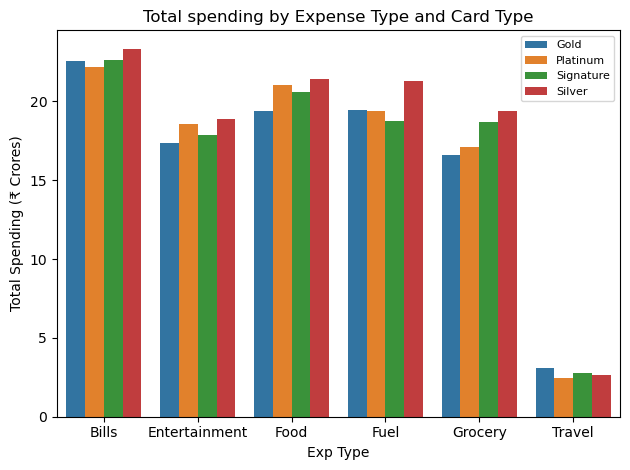

In [65]:
sns.barplot(data = card_exp_spending,x = 'Exp Type',y='Amount Crore',hue='Card Type')
plt.title('Total spending by Expense Type and Card Type')
plt.ylabel('Total Spending (₹ Crores)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Observations
1) Bills represent the highest spending category across all card types.
2) Travel is the lowest spending category across all card types.
3) Silver card holders contribute the highest spending in most expense categories.
4) Food, Fuel, and Bills are the dominant spending categories regardless of card type.
5) Spending patterns are broadly similar across card types, with differences mainly in spending magnitude rather than category preference.

## Key Findings

1. Greater Mumbai contributes the highest spending.
2. Silver cards generate the highest total spending.
3. Bills are the dominant expense category.
4. Female customers contribute higher total and average spending.
5. Female customers spend significantly more on Bills and Food.
6. Travel is the lowest spending category across genders and card types.
7. Spending patterns are broadly similar across all card types.

## Conclusion

This analysis explored credit card spending patterns across cities, card types, expense categories, and customer demographics. The results show that spending is concentrated in major metropolitan cities, Bills are the dominant expense category, and female customers contribute higher spending than male customers. Travel remains the least significant spending category across both genders and card types.